In [1]:
import matplotlib.pyplot as plt
import xarray as xr
from dask.diagnostics import ProgressBar
import hvplot.xarray
import numpy as np, matplotlib.pyplot as plt, imageio.v2 as imageio
import math
import rioxarray


In [2]:
import xarray as xr

cube_paths = [
    "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/antarctica_cube/icetemp.zarr",
    "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/antarctica_cube/sec.zarr",
    "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/antarctica_cube/antarctica-combined.zarr",
    "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/antarctica_cube/icemask_composite.zarr/"
]

ds = xr.open_mfdataset(cube_paths, engine="zarr",chunks={},compat='no_conflicts')
ds

<xarray.Dataset> Size: 3TB
Dimensions:                                    (y: 49158, x: 57358, depth: 91,
                                                time_period: 27, time: 24)
Coordinates:
  * y                                          (y) float32 197kB -2.458e+06 ....
  * x                                          (x) float32 229kB -2.868e+06 ....
  * depth                                      (depth) int16 182B 0 50 ... 4500
  * time_period                                (time_period) int64 216B 0 ... 26
  * time                                       (time) datetime64[ns] 192B 199...
    spatial_ref                                int64 8B 0
Data variables: (12/33)
    englacial_temp_profile_quality_flag        (y, x) float16 6GB dask.array<chunksize=(4915, 5735), meta=np.ndarray>
    englacial_temp_profile_tice                (depth, y, x) float16 513GB dask.array<chunksize=(1, 4915, 5735), meta=np.ndarray>
    surface_elevation_change_basin_id          (y, x) float32 11GB dask.array<chunksize=(4915, 5735), meta=np.ndarray>
    surface_elevation_change_cell_end_times    (time_period, y, x) float32 305GB dask.array<chunksize=(1, 4915, 5735), meta=np.ndarray>
    surface_elevation_change_cell_start_times  (time_period, y, x) float32 305GB dask.array<chunksize=(1, 4915, 5735), meta=np.ndarray>
    surface_elevation_change_end_time          (time_period) float32 108B dask.array<chunksize=(1,), meta=np.ndarray>
    ...                                         ...
    groundlines_orbit4                         (y, x) float32 11GB dask.array<chunksize=(4915, 5735), meta=np.ndarray>
    groundlines_sensor                         (y, x) uint8 3GB dask.array<chunksize=(4915, 5735), meta=np.ndarray>
    ice_shelf_basal_melt_rate                  (y, x) float32 11GB dask.array<chunksize=(4915, 5735), meta=np.ndarray>
    subglacial_lakes_mask                      (y, x) uint8 3GB dask.array<chunksize=(4915, 5735), meta=np.ndarray>
    supra_glacial_lakes_mask                   (y, x) uint8 3GB dask.array<chunksize=(4915, 5735), meta=np.ndarray>
    calving_fronts                             (time, y, x) float64 541GB dask.array<chunksize=(1, 4915, 5735), meta=np.ndarray>

In [3]:
minx, miny,maxx, maxy = -1657448.0-60000, -544313.0-20000, -1516351.0401517956, -381472.01474966406


In [4]:

b_melt = ds.ice_shelf_basal_melt_rate.sel(x=slice(minx, maxx), y=slice(miny, maxy)).hvplot()
ds.calving_fronts.sel(x=slice(minx, maxx), y=slice(miny, maxy)).hvplot(groupby='time') * b_melt


ModuleNotFoundError: No module named 'jupyter_bokeh'

:DynamicMap   [time]

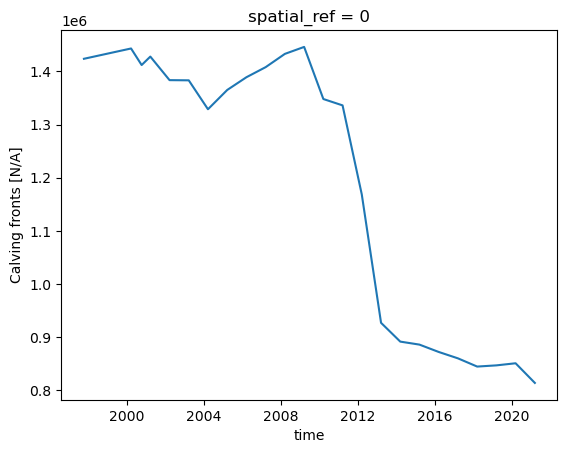

In [5]:
ds.calving_fronts.sel(x=slice(minx, maxx), y=slice(miny, maxy)).sum(dim=["x", "y"]).plot()

In [6]:
import xarray as xr
ds = xr.open_zarr("https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/s14science_amazonas/s14science_amazonas_tree_cover_change.zarr")
ds

<xarray.Dataset> Size: 22TB
Dimensions:            (time: 194, lat: 146501, lon: 190847)
Coordinates:
  * time               (time) datetime64[ns] 2kB 2017-01-02 ... 2024-11-29
  * lat                (lat) float64 1MB 9.047 9.046 9.046 ... -17.27 -17.27
  * lon                (lon) float64 2MB -79.2 -79.2 -79.2 ... -44.91 -44.91
    spatial_ref        int64 8B ...
Data variables:
    tree_cover_change  (time, lat, lon) float32 22TB dask.array<chunksize=(1, 5120, 5120), meta=np.ndarray>
Attributes:
    geospatial_lon_resolution:  0.00017966
    geospatial_lat_resolution:  0.00017966
    description:                The Sentinel-1 for Science Amazonas project d...
    license:                    Creative Commons Attribution 4.0 Internationa...
    license_url:                https://creativecommons.org/licenses/by/4.0/
    references:                 https://sen4ama.gisat.cz/ https://eo4society....
    platform:                   Sentinel-1
    project:                    Sentinel-1 for Science Amazonas
    keywords:                   Forests, Deforestation, SAR, Amazon, Sentinel-1

/opt/miniconda3/envs/pangeo/lib/python3.13/site-packages/dask/array/reductions.py:325: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


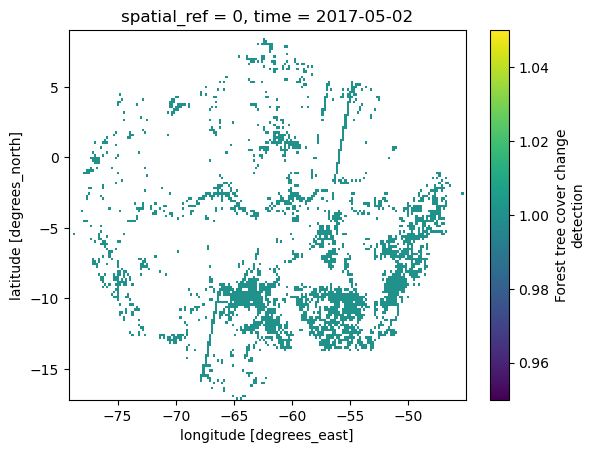

In [7]:
ds.isel(time=10).tree_cover_change.coarsen(lat=1000, lon=1000, boundary="trim").max().plot()